# Blok A — Lengan usulan vs baseline (klaim utama)

Menjalankan Blok A pada `RENCANA_ANALISIS_HASIL.md`. **Tanpa eksperimen baru.**

> ## Versi terkoreksi (2026-08-31)
>
> Notebook ini menggantikan versi pertama yang mengandung **tiga ketidaksetaraan**
> dan **satu metrik salah-besaran**. Rinciannya di `AUDIT_METRIK.md`. Ringkas:
>
> 1. **`gini` mengukur besaran yang salah.** Yang tersimpan dihitung dari `total_served`
>    (cacah transaksi), sedangkan Tujuan Kinerja 1 menuntut ketimpangan **utilisasi**.
>    Reward pelatihan sendiri sudah memakai utilisasi (`rollout.py:607`), jadi yang
>    keliru hanya pelaporan — **tidak perlu latih ulang**. Dikoreksi lewat
>    `A.gini_stasiun()`, dihitung dari `_stasiun` yang sudah tersimpan.
> 2. **Baseline greedy tidak setara** pada estimator, ukuran himpunan rekomendasi
>    (k=2 vs 3), dan cakupan kanal janji. Ketiganya menguntungkan greedy. Notebook ini
>    memakai `greedy_setara_k3` (10 run), bukan berkas `greedy` lama.
> 3. **Keempat sel faktorial disertakan**, bukan hanya sel4 — perbandingan antar-sel
>    diperlukan untuk menjelaskan mengapa hanya sel4 yang kompetitif.
> 4. **Baseline dipersempit ke `greedy_queue` saja.** `greedy_util` menilai stasiun dengan `(antre+charging)/kapasitas` — yaitu okupansi, besaran yang **sama** dengan yang diukur `gini_UTIL`. Ia karena itu melakukan penurunan langsung pada fungsi tujuan evaluasi (sifat ini didokumentasikan di docstring `GreedyAgent`), sehingga bersifat sirkular sebagai pembanding. `greedy_queue` memakai panjang antrean mentah — sinyal yang berbeda dari metrik evaluasi — dan sejalan dengan *minimum queuing mechanism* pada Lin dkk. (2024).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import _analisis_bab5 as A

pd.set_option('display.width', 230); pd.set_option('display.max_columns', 60)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 9, 'axes.grid': True,
                     'grid.alpha': .3, 'figure.figsize': (9, 4)})

HORIZON, WARMUP = '90d', 7
B = 'master_hybrid_ppo_dgr_90d_cwtfail120pen-2_preffeat_pairout'

SEL = [('sel1 mati',    f'{B}_noattn_pure3',       None),
       ('sel2 attn',    f'{B}_pure3',              None),
       ('sel3 P',       f'{B}_pg0.1_noattn_pure3', None),
       ('sel4 attn+P',  f'{B}_pg0.1_pure3',        None)]
GREEDY = [('greedy_queue', 'greedy_setara_k3', 'greedy_queue|signed|dinamis')]
LENGAN = SEL + GREEDY
USULAN = SEL[3]

for n, t, l in LENGAN:
    _, _, v, lab = A.unit_stat(t, 'acc', HORIZON, l)
    print(f'{n:14s} n={len(v):2d} unit={lab}')

sel1 mati      n= 3 unit=checkpoint
sel2 attn      n= 3 unit=checkpoint
sel3 P         n= 3 unit=checkpoint
sel4 attn+P    n= 3 unit=checkpoint
greedy_queue   n=10 unit=run


> **Ketidakseimbangan n.** Lengan RL punya 3 checkpoint (melatih ulang tak
> memungkinkan), greedy 10 run. Perbandingan **rerata** sah; perbandingan **lebar
> sebaran** condong menguntungkan lengan ber-n kecil. Jangan simpulkan "RL lebih
> stabil" dari SD saja.

## A.1 — Pemeriksaan kolaps checkpoint

RENCANA §2.3: didahulukan, karena bila ada checkpoint kolaps seluruh tabel berikutnya
harus dibaca dengan itu di kepala. Checkpoint kolaps **tidak dibuang**.

In [2]:
for n, t, l in SEL:
    k = A.deteksi_kolaps(t, HORIZON, l)
    print(f'{n:14s} kolaps={int(k["kolaps"].sum())}/{len(k)}  '
          f'n_pola_cocok={list(k["n_pola_cocok"])}')

sel1 mati      kolaps=0/3  n_pola_cocok=[0, 0, 1]
sel2 attn      kolaps=0/3  n_pola_cocok=[3, 0, 1]
sel3 P         kolaps=0/3  n_pola_cocok=[2, 2, 0]
sel4 attn+P    kolaps=0/3  n_pola_cocok=[0, 0, 1]


## A.2 — Pemerataan: KOREKSI metrik

Empat pengertian pemerataan yang berbeda. Hanya `gini_UTIL` yang sesuai Tujuan
Kinerja 1 ("penurunan ketimpangan **utilisasi** jaringan", baseline Gini utilisasi
0,802).

Divergensinya berasal dari heterogenitas stasiun: kapasitas 1/2/4/4/4/2 konektor,
dan DC melayani ~3x lebih cepat dari AC. Transaksi merata **tidak** berarti utilisasi
merata.

In [3]:
baris = []
for n, t, l in LENGAN:
    baris.append({
        'lengan': n,
        'gini_UTIL (TK1)':   A.gini_stasiun(t, 'gini_utilisasi', HORIZON, l)[0],
        'gini_ANTREAN':      A.gini_stasiun(t, 'gini_antrean',   HORIZON, l)[0],
        'gini_wait_pengguna': A.unit_stat(t, 'gini_wait_pengguna', HORIZON, l)[0],
        'gini_transaksi (lama)': A.unit_stat(t, 'gini', HORIZON, l)[0]})
eq = pd.DataFrame(baris).set_index('lengan')
display(eq.round(4))

print('Peringkat menurut gini_UTIL (sesuai TK1):')
for i, (n, v) in enumerate(eq['gini_UTIL (TK1)'].sort_values().items(), 1):
    print(f'  {i}. {n:14s} {v:.4f}')
print()
print('>> Keempat sel RL mengungguli greedy_queue pada metrik yang benar.')
print('>> Metrik lama (transaksi) memberi peringkat KEBALIKANNYA.')

,gini_UTIL (TK1),gini_ANTREAN,gini_wait_pengguna,gini_transaksi (lama)
lengan,,,,
sel1 mati,0.0289,0.0929,0.3870,0.1150
sel2 attn,0.0393,0.1216,0.4003,0.1252
sel3 P,0.0521,0.1447,0.3975,0.1366
sel4 attn+P,0.0206,0.0690,0.4085,0.1188
greedy_queue,0.1163,0.2232,0.5066,0.0656


Peringkat menurut gini_UTIL (sesuai TK1):
  1. sel4 attn+P    0.0206
  2. sel1 mati      0.0289
  3. sel2 attn      0.0393
  4. sel3 P         0.0521
  5. greedy_queue   0.1163

>> Keempat sel RL mengungguli greedy_queue pada metrik yang benar.
>> Metrik lama (transaksi) memberi peringkat KEBALIKANNYA.


In [4]:
# keterpisahan rentang pada metrik TK1
u = A.gini_stasiun(USULAN[1], 'gini_utilisasi', HORIZON, USULAN[2])[2]
print(f'sel4 rentang gini_UTIL: [{u.min():.4f}, {u.max():.4f}]\n')
for n, t, l in SEL[:3] + GREEDY:
    o = A.gini_stasiun(t, 'gini_utilisasi', HORIZON, l)[2]
    sep = 'TERPISAH' if (u.max() < o.min() or o.max() < u.min()) else 'tindih'
    print(f'  vs {n:14s} [{o.min():.4f}, {o.max():.4f}]  -> {sep}')

sel4 rentang gini_UTIL: [0.0171, 0.0273]

  vs sel1 mati      [0.0188, 0.0415]  -> tindih
  vs sel2 attn      [0.0260, 0.0562]  -> tindih
  vs sel3 P         [0.0368, 0.0668]  -> TERPISAH
  vs greedy_queue   [0.1127, 0.1203]  -> TERPISAH


## A.3 — Tabel perbandingan utama

In [5]:
M_INTI = ['acc', 'wait', 'trust', 'rec_entropy', 'herding']
baris = []
for n, t, l in LENGAN:
    r = {'lengan': n, 'gini_UTIL': A.gini_stasiun(t, 'gini_utilisasi', HORIZON, l)[0]}
    for m in M_INTI:
        r[m] = A.unit_stat(t, m, HORIZON, l)[0]
    baris.append(r)
tab = pd.DataFrame(baris).set_index('lengan')
A.ARAH_BAIK['gini_UTIL'] = 'min'
display(A.sorot_terbaik(tab, ['gini_UTIL'] + M_INTI))

,gini_UTIL,acc,wait,trust,rec_entropy,herding
lengan,,,,,,
sel1 mati,0.0289,0.6700,95.9557,0.3666,0.0602,0.3658
sel2 attn,0.0393,0.7021,89.6613,0.3935,0.0788,0.3471
sel3 P,0.0521,0.7034,84.1083,0.3960,0.0747,0.3499
sel4 attn+P,0.0206,0.7194,66.2480,0.4348,0.1182,0.3063
greedy_queue,0.1163,0.7165,39.0510,0.4366,0.0000,0.4255


## A.4 — Verifikasi tiga Tujuan Kinerja (III.2.3)

| # | Tujuan | Metrik | Sifat klaim |
|---|---|---|---|
| 1 | Penurunan ketimpangan **utilisasi** | `gini_UTIL` | kondisi akhir |
| 2 | Peningkatan penerimaan | `acc` | kondisi akhir |
| 3 | Stabilitas kepercayaan **sepanjang operasi** | lintasan `trust_mean` | **lintasan** |

In [6]:
baris = []
for n, t, l in LENGAN:
    tr = A.slope_dan_auc(t, 'trust_mean', HORIZON, l, WARMUP)
    baris.append({'lengan': n,
        'TK1 gini_UTIL': A.gini_stasiun(t, 'gini_utilisasi', HORIZON, l)[0],
        'TK2 acc':       A.unit_stat(t, 'acc', HORIZON, l)[0],
        'TK3 trust_awal10h':  tr['awal_10h'], 'TK3 trust_akhir10h': tr['akhir_10h'],
        'TK3 slope/hari': f"{tr['slope']:+.2e}",
        'TK3 terpenuhi': 'YA' if tr['akhir_10h'] >= tr['awal_10h'] else 'TIDAK (menurun)'})
display(pd.DataFrame(baris).set_index('lengan').round(4))
print('TK3 menuntut lintasan TIDAK menurun. Menurun di SEMUA lengan termasuk greedy')
print('-> tampak properti lingkungan, bukan kegagalan metode. Perlu dinyatakan.')

,TK1 gini_UTIL,TK2 acc,TK3 trust_awal10h,TK3 trust_akhir10h,TK3 slope/hari,TK3 terpenuhi
lengan,,,,,,
sel1 mati,0.0289,0.6700,0.4745,0.3731,-1.41e-03,TIDAK (menurun)
sel2 attn,0.0393,0.7021,0.4808,0.3934,-1.22e-03,TIDAK (menurun)
sel3 P,0.0521,0.7034,0.4834,0.4020,-1.14e-03,TIDAK (menurun)
sel4 attn+P,0.0206,0.7194,0.4942,0.4401,-7.80e-04,TIDAK (menurun)
greedy_queue,0.1163,0.7165,0.4912,0.4409,-7.08e-04,TIDAK (menurun)


TK3 menuntut lintasan TIDAK menurun. Menurun di SEMUA lengan termasuk greedy
-> tampak properti lingkungan, bukan kegagalan metode. Perlu dinyatakan.


## A.5 — Waktu tunggu: MENERIMA vs MENOLAK rekomendasi

Waktu tunggu pengguna yang **menolak** bukan konsekuensi rekomendasi; mencampurnya
dengan yang menerima adalah salah atribusi.

In [7]:
P = ['mean', 'p50', 'p75', 'p90', 'p95', 'p99']
for pre, judul in [('wpatuh', 'MENERIMA rekomendasi'), ('wtolak', 'MENOLAK rekomendasi')]:
    baris = []
    for n, t, l in LENGAN:
        r = {'lengan': n}
        for p in P:
            r[p] = A.unit_stat(t, f'{pre}_{p}', HORIZON, l)[0]
        baris.append(r)
    print(f'\n=== waktu tunggu (menit) — {judul} ===')
    display(pd.DataFrame(baris).set_index('lengan').round(2))


=== waktu tunggu (menit) — MENERIMA rekomendasi ===


,mean,p50,p75,p90,p95,p99
lengan,,,,,,
sel1 mati,100.39,68.70,156.64,253.84,322.06,471.32
sel2 attn,90.72,54.10,144.63,240.08,301.37,431.94
sel3 P,79.23,43.95,125.67,214.88,277.17,419.03
sel4 attn+P,51.00,23.04,79.67,146.21,192.85,299.26
greedy_queue,24.37,0.00,34.85,79.84,114.24,195.34



=== waktu tunggu (menit) — MENOLAK rekomendasi ===


,mean,p50,p75,p90,p95,p99
lengan,,,,,,
sel1 mati,90.70,46.52,138.98,241.79,319.18,526.89
sel2 attn,95.45,56.95,142.50,242.57,315.45,493.01
sel3 P,98.38,67.88,150.21,243.19,310.24,491.81
sel4 attn+P,105.34,84.02,160.70,244.01,302.28,463.55
greedy_queue,76.18,51.43,119.28,194.09,251.89,392.34


In [8]:
# Nilai mengikuti rekomendasi -- selisih dihitung PER-UNIT agar SD-nya bermakna
baris = []
for n, t, l in LENGAN:
    wp = A.unit_stat(t, 'wpatuh_mean', HORIZON, l)
    wt = A.unit_stat(t, 'wtolak_mean', HORIZON, l)
    d = wt[2] - wp[2]
    baris.append({'lengan': n, 'wpatuh': wp[0], 'wtolak': wt[0],
                  'nilai_ikut': d.mean(), 'sd': d.std(ddof=0),
                  'n_patuh': A.unit_stat(t, 'wpatuh_n', HORIZON, l)[0]})
nilai = pd.DataFrame(baris).set_index('lengan')
display(nilai.round(2))

print('nilai_ikut = wtolak_mean - wpatuh_mean  (positif = mengikuti lebih baik)\n')
print('>> sel1 NEGATIF: mengikuti rekomendasinya JUSTRU MERUGIKAN pengguna.')
print('   Ini menjelaskan trust & acc terendahnya -- sistem itu memang tak layak diikuti.')
print('>> Naik monoton sel1->sel4; sel4 TERTINGGI dari seluruh lengan (melampaui greedy).')
print('>> Bukan artefak seleksi: jumlah yang patuh JUGA naik (11.173 -> 12.000).')

,wpatuh,wtolak,nilai_ikut,sd,n_patuh
lengan,,,,,
sel1 mati,100.39,90.70,-9.68,50.67,11172.89
sel2 attn,90.72,95.45,4.73,64.92,11707.69
sel3 P,79.23,98.38,19.14,42.74,11728.06
sel4 attn+P,51.00,105.34,54.33,5.54,12000.39
greedy_queue,24.37,76.18,51.82,3.27,11966.90


nilai_ikut = wtolak_mean - wpatuh_mean  (positif = mengikuti lebih baik)

>> sel1 NEGATIF: mengikuti rekomendasinya JUSTRU MERUGIKAN pengguna.
   Ini menjelaskan trust & acc terendahnya -- sistem itu memang tak layak diikuti.
>> Naik monoton sel1->sel4; sel4 TERTINGGI dari seluruh lengan (melampaui greedy).
>> Bukan artefak seleksi: jumlah yang patuh JUGA naik (11.173 -> 12.000).


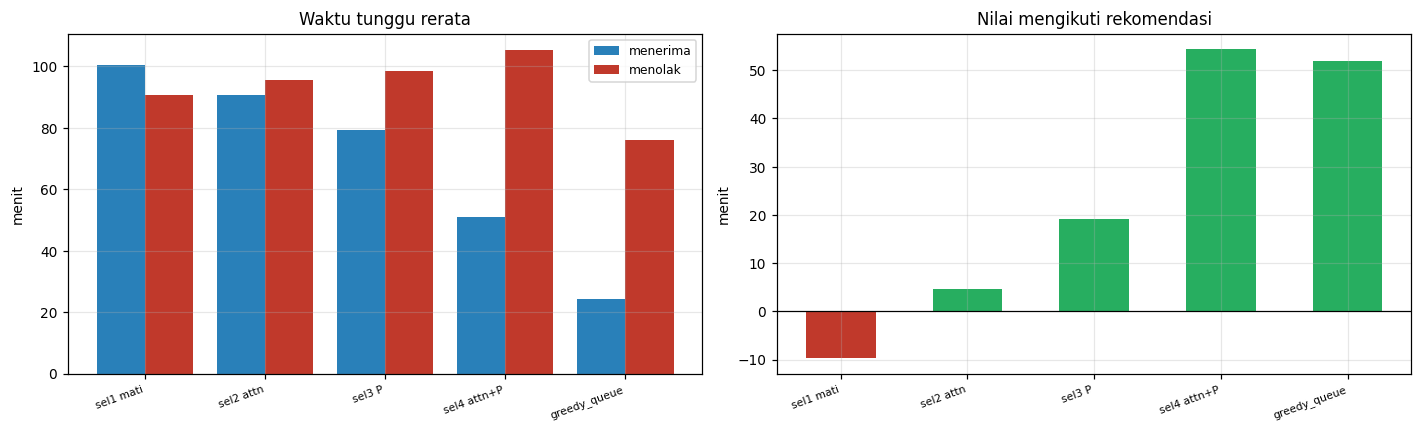

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
x = np.arange(len(LENGAN)); nm = [n for n, _, _ in LENGAN]
wp = [A.unit_stat(t, 'wpatuh_mean', HORIZON, l)[0] for _, t, l in LENGAN]
wt = [A.unit_stat(t, 'wtolak_mean', HORIZON, l)[0] for _, t, l in LENGAN]
ax[0].bar(x - .2, wp, .4, label='menerima', color='#2980b9')
ax[0].bar(x + .2, wt, .4, label='menolak', color='#c0392b')
ax[0].set_xticks(x); ax[0].set_xticklabels(nm, rotation=20, ha='right', fontsize=7)
ax[0].set_ylabel('menit'); ax[0].set_title('Waktu tunggu rerata'); ax[0].legend(fontsize=8)
v = nilai['nilai_ikut'].values
ax[1].bar(x, v, .55, color=['#c0392b' if a < 0 else '#27ae60' for a in v])
ax[1].axhline(0, color='k', lw=.8)
ax[1].set_xticks(x); ax[1].set_xticklabels(nm, rotation=20, ha='right', fontsize=7)
ax[1].set_ylabel('menit'); ax[1].set_title('Nilai mengikuti rekomendasi')
plt.tight_layout(); plt.show()

## A.6 — Manfaat ke pengguna

`acc` mengukur **apakah saran diikuti**, bukan **apakah yang mengikuti jadi lebih
baik**. Kontrafaktualnya `sid_pref` = stasiun pilihan pengguna tanpa rekomendasi.

> Metrik ini kini **sebanding**: sejak `_uji_greedy_setara_metrik.py`, greedy juga
> memberi `inf` ke stasiun non-rekomendasi, sehingga kedua kelompok sama-sama
> membuang kasus "preferensi di luar rekomendasi". Cakupannya menyempit — wajib
> dinyatakan — tetapi tidak lagi asimetris.

In [10]:
baris = []
for n, t, l in LENGAN:
    acc = A.unit_stat(t, 'acc', HORIZON, l)[0]
    fu  = A.unit_stat(t, 'jnpatuh_expost_frac_untung', HORIZON, l)[0]
    hm  = A.unit_stat(t, 'jnpatuh_expost_mean', HORIZON, l)[0]
    baris.append({'lengan': n, 'acc': acc, 'frac_untung|patuh': fu,
                  'hemat_mnt|patuh': hm, 'frac_untung_total': acc * fu,
                  'hemat_per_keputusan': acc * hm})
display(pd.DataFrame(baris).set_index('lengan').round(4))

,acc,frac_untung|patuh,hemat_mnt|patuh,frac_untung_total,hemat_per_keputusan
lengan,,,,,
sel1 mati,0.6700,0.5298,17.6033,0.3550,11.7951
sel2 attn,0.7021,0.4995,17.3210,0.3507,12.1605
sel3 P,0.7034,0.5113,17.6827,0.3597,12.4376
sel4 attn+P,0.7194,0.5385,20.6793,0.3874,14.8765
greedy_queue,0.7165,0.4074,11.0938,0.2919,7.9489


## A.7 — Kalibrasi janji: `pct_tepat` terkonfound dengan perutean

Ambang toleransi **TOL_LOW = 2,10 menit** (~7% dari rerata tunggu baseline 30,4 mnt) —
sangat ketat. Konsekuensinya `pct_tepat` pada dasarnya mengukur **berapa banyak trip
yang antreannya nol**, bukan kualitas prediktor.

Terukur pada greedy (30d, seed 0): dari trip ber-`wait = 0`, **78,8–84,5%** dinilai
tepat; dari trip ber-`wait > 0`, hanya **~39,4–39,8%** — dan angka ~40% itu **sama**
untuk semua lengan karena forecasternya identik.

Jadi `pct_tepat` tinggi pada greedy adalah **akibat sampingan merutekan ke stasiun
kosong**, bukan bukti estimasi yang lebih baik.

In [11]:
baris = []
for n, t, l in LENGAN:
    baris.append({'lengan': n,
        'wpatuh_p50': A.unit_stat(t, 'wpatuh_p50', HORIZON, l)[0],
        'pct_tepat':  A.unit_stat(t, 'pct_tepat',  HORIZON, l)[0],
        'pct_telat':  A.unit_stat(t, 'pct_telat',  HORIZON, l)[0],
        'galat_mean': A.unit_stat(t, 'galat_mean', HORIZON, l)[0],
        'trust':      A.unit_stat(t, 'trust',      HORIZON, l)[0],
        'acc':        A.unit_stat(t, 'acc',        HORIZON, l)[0]})
kal = pd.DataFrame(baris).set_index('lengan')
display(kal.round(4))

x = kal['wpatuh_p50'].values
print('Korelasi median tunggu pengguna patuh terhadap:')
for m in ['pct_tepat', 'pct_telat', 'trust', 'acc']:
    print(f'   {m:10s} r = {np.corrcoef(x, kal[m].values)[0,1]:+.4f}')
print()
print('>> Rantai sebab: rute ke stasiun berantre -> tunggu tak nol -> janji mustahil')
print('   akurat pada toleransi 2 mnt -> trust tergerus -> penerimaan turun.')

,wpatuh_p50,pct_tepat,pct_telat,galat_mean,trust,acc
lengan,,,,,,
sel1 mati,68.6977,28.2528,27.2745,-3.0416,0.3666,0.6700
sel2 attn,54.0996,34.9973,23.8835,-3.8915,0.3935,0.7021
sel3 P,43.9456,34.6041,23.3575,-4.7489,0.3960,0.7034
sel4 attn+P,23.0428,37.7053,18.4151,-8.8177,0.4348,0.7194
greedy_queue,0.0000,51.5098,20.6974,-0.1669,0.4366,0.7165


Korelasi median tunggu pengguna patuh terhadap:
   pct_tepat  r = -0.9449
   pct_telat  r = +0.8385
   trust      r = -0.9511
   acc        r = -0.8444

>> Rantai sebab: rute ke stasiun berantre -> tunggu tak nol -> janji mustahil
   akurat pada toleransi 2 mnt -> trust tergerus -> penerimaan turun.


> **Catatan metrik (AUDIT_METRIK.md §2.1):** `trust` dan `frac_trust_rendah`
> dirata-ratakan atas SELURUH 2.636 pengguna, termasuk yang tak pernah diperbarui
> (24,2% bernilai persis prior 0,5). `trust` nyaris tak terpengaruh, tetapi
> `frac_trust_rendah` **dikecilkan ~23% relatif**. Pengenceran identik di semua lengan
> sehingga urutan tetap sah.

## A.8 — Koordinasi

> **Dua catatan penting** (AUDIT_METRIK.md §2.2–2.3):
> - `rec_entropy`/`herding` hanya menghitung rekomendasi **primer** (`recs[0]`).
>   Dengan k=3, dua dari tiga stasiun yang dilihat pengguna tak masuk hitungan.
>   `rec_entropy = 0` pada greedy **benar** dan bermakna "tidak ada personalisasi":
>   `GreedyAgent._score()` menilai stasiun tanpa melihat pengguna, sehingga seluruh
>   pengguna serentak menerima primer identik.
> - `flocking` **tidak** ternormalisasi ke [0,1]; ambang ≤0,20 di draf tesis belum
>   diverifikasi skalanya. Jangan dipakai sebagai kriteria lulus.

In [12]:
baris = []
for n, t, l in LENGAN:
    r = {'lengan': n}
    for m in ['rec_entropy', 'herding', 'flocking', 'entropi_spklu_pengguna']:
        r[m] = A.unit_stat(t, m, HORIZON, l)[0]
    baris.append(r)
display(pd.DataFrame(baris).set_index('lengan').round(4))
print('herding & flocking BERLAWANAN arah: greedy memusatkan rekomendasi (herding tinggi)')
print('tetapi ke stasiun yang memang kosong, sehingga antreannya tak tumbuh (flocking rendah).')

,rec_entropy,herding,flocking,entropi_spklu_pengguna
lengan,,,,
sel1 mati,0.0602,0.3658,0.1158,0.8044
sel2 attn,0.0788,0.3471,0.0909,0.8433
sel3 P,0.0747,0.3499,0.0916,0.8485
sel4 attn+P,0.1182,0.3063,0.0687,0.8974
greedy_queue,0.0000,0.4255,0.0060,0.9037


herding & flocking BERLAWANAN arah: greedy memusatkan rekomendasi (herding tinggi)
tetapi ke stasiun yang memang kosong, sehingga antreannya tak tumbuh (flocking rendah).


## A.9 — Efek faktorial attention x Modul P

In [13]:
S = {n: t for n, t, _ in SEL}
def val(t, m):
    if m == 'gini_UTIL':  return A.gini_stasiun(t, 'gini_utilisasi', HORIZON)[0]
    if m == 'gini_ANTRE': return A.gini_stasiun(t, 'gini_antrean',   HORIZON)[0]
    return A.unit_stat(t, m, HORIZON)[0]

M = ['gini_UTIL', 'gini_ANTRE', 'acc', 'wait', 'trust', 'pct_tepat', 'pct_telat',
     'jnpatuh_expost_frac_untung', 'jnpatuh_expost_mean', 'rec_entropy', 'herding']
baris = []
for m in M:
    v = {k: val(t, m) for k, t in S.items()}
    s1, s2, s3, s4 = (v['sel1 mati'], v['sel2 attn'], v['sel3 P'], v['sel4 attn+P'])
    baris.append({'metrik': m, 'sel1': s1, 'sel2': s2, 'sel3': s3, 'sel4': s4,
                  'efek_attn': (s2+s4)/2 - (s1+s3)/2,
                  'efek_P':    (s3+s4)/2 - (s1+s2)/2,
                  'interaksi': (s4-s3) - (s2-s1)})
fak = pd.DataFrame(baris).set_index('metrik')
display(fak.round(4))

r = fak.loc['gini_UTIL']
print(f"Pada gini_UTIL (metrik inti TK1):")
print(f"   efek_attn = {r['efek_attn']:+.5f}   efek_P = {r['efek_P']:+.5f}"
      f"   interaksi = {r['interaksi']:+.5f}")
print('>> Interaksi JAUH melampaui kedua efek utama, dan tandanya menguntungkan.')
print('   Urutannya sel4 < sel1 < sel2 < sel3: masing-masing komponen SENDIRIAN')
print('   MEMPERBURUK pemerataan, tetapi bersama menjadi yang terbaik.')
print('   -> komplementaritas murni, bukan aditif.')

,sel1,sel2,sel3,sel4,efek_attn,efek_P,interaksi
metrik,,,,,,,
gini_UTIL,0.0289,0.0393,0.0521,0.0206,-0.0106,0.0023,-0.0419
gini_ANTRE,0.0929,0.1216,0.1447,0.0690,-0.0235,-0.0004,-0.1044
acc,0.6700,0.7021,0.7034,0.7194,0.0240,0.0253,-0.0160
wait,95.9557,89.6613,84.1083,66.2480,-12.0773,-17.6303,-11.5660
trust,0.3666,0.3935,0.3960,0.4348,0.0328,0.0353,0.0118
pct_tepat,28.2528,34.9973,34.6041,37.7053,4.9229,4.5297,-3.6433
pct_telat,27.2745,23.8835,23.3575,18.4151,-4.1667,-4.6927,-1.5514
jnpatuh_expost_frac_untung,0.5298,0.4995,0.5113,0.5385,-0.0015,0.0103,0.0575
jnpatuh_expost_mean,17.6033,17.3210,17.6827,20.6793,1.3571,1.7189,3.2790


Pada gini_UTIL (metrik inti TK1):
   efek_attn = -0.01058   efek_P = +0.00229   interaksi = -0.04188
>> Interaksi JAUH melampaui kedua efek utama, dan tandanya menguntungkan.
   Urutannya sel4 < sel1 < sel2 < sel3: masing-masing komponen SENDIRIAN
   MEMPERBURUK pemerataan, tetapi bersama menjadi yang terbaik.
   -> komplementaritas murni, bukan aditif.


## A.10 — Mengapa sel lain tidak dapat belajar seperti sel4

Jawabannya ada di **proses pelatihan**, bukan pada hasil akhir: penyeimbang DGR
kehilangan kendali pada sel1/sel2.

Bobot DGR dihitung dari *gap-ratio* — aliran yang performanya masih jauh dari acuan
spesialisnya mendapat bobot lebih besar. Mekanisme itu mengandaikan kebijakan **mampu**
menutup gap bila diberi bobot. Tanpa attention (buta terhadap kandidat lain) atau
tanpa Modul P (tak dapat membedakan pengguna), gap aliran `gini` **tidak pernah
menutup**; DGR menaikkan bobotnya lagi, dan lingkaran itu swa-penguat sampai dua
aliran lain kelaparan.

In [14]:
for n, t, _ in SEL:
    b  = A.beta_akhir(t)
    gu = A.gini_stasiun(t, 'gini_utilisasi', HORIZON)[2]
    w  = A.unit_stat(t, 'wait', HORIZON)[2]
    ac = A.unit_stat(t, 'acc',  HORIZON)[2]
    print(f'--- {n}   (SD antar-seed pada beta_wait = {b["wait"].std(ddof=0):.4f})')
    for i, (s, row) in enumerate(b.iterrows()):
        tanda = '  <== DGR KOLAPS ke gini' if row['gini'] > 0.6 else ''
        print(f'   ckpt{i}: beta=[w{row["wait"]:.2f} g{row["gini"]:.2f} '
              f'a{row["accept"]:.2f}]  gini_util={gu[i]:.4f}  wait={w[i]:6.2f}  '
              f'acc={ac[i]:.4f}{tanda}')
    print()

--- sel1 mati   (SD antar-seed pada beta_wait = 0.2513)
   ckpt0: beta=[w0.57 g0.28 a0.16]  gini_util=0.0265  wait= 92.40  acc=0.6734
   ckpt1: beta=[w0.05 g0.92 a0.03]  gini_util=0.0415  wait= 76.38  acc=0.6997  <== DGR KOLAPS ke gini
   ckpt2: beta=[w0.59 g0.19 a0.21]  gini_util=0.0188  wait=119.08  acc=0.6370

--- sel2 attn   (SD antar-seed pada beta_wait = 0.2979)
   ckpt0: beta=[w0.77 g0.19 a0.04]  gini_util=0.0562  wait=135.89  acc=0.6479
   ckpt1: beta=[w0.04 g0.95 a0.00]  gini_util=0.0260  wait= 63.46  acc=0.7301  <== DGR KOLAPS ke gini
   ckpt2: beta=[w0.32 g0.62 a0.06]  gini_util=0.0357  wait= 69.64  acc=0.7282  <== DGR KOLAPS ke gini

--- sel3 P   (SD antar-seed pada beta_wait = 0.1255)
   ckpt0: beta=[w0.83 g0.07 a0.11]  gini_util=0.0668  wait= 83.16  acc=0.7026
   ckpt1: beta=[w0.62 g0.17 a0.21]  gini_util=0.0529  wait=105.60  acc=0.6800
   ckpt2: beta=[w0.53 g0.46 a0.01]  gini_util=0.0368  wait= 63.57  acc=0.7276

--- sel4 attn+P   (SD antar-seed pada beta_wait = 0.0930)


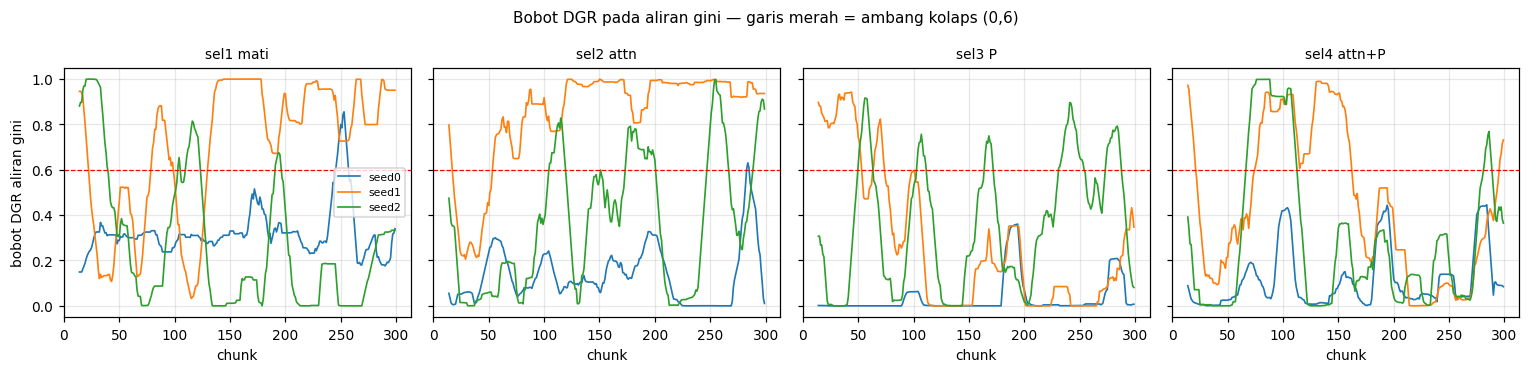

sel1 & sel2 punya seed yang terkunci >0,9 pada aliran gini -- kebijakan itu
praktis berhenti mengoptimasi wait dan acceptance. sel4 tidak pernah begitu:
ketiga seed mendarat di pita sempit (beta_wait 0,60-0,80).


In [15]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.4), sharey=True)
for ax, (n, t, _) in zip(axes, SEL):
    for seed, df in A.kurva_vektor(t, 'beta').items():
        ax.plot(df.index, df['gini'].rolling(15).mean(), lw=1.1, label=f'seed{seed}')
    ax.axhline(0.6, color='r', ls='--', lw=.8)
    ax.set_title(n, fontsize=9); ax.set_xlabel('chunk')
axes[0].set_ylabel('bobot DGR aliran gini'); axes[0].legend(fontsize=7)
plt.suptitle('Bobot DGR pada aliran gini — garis merah = ambang kolaps (0,6)', fontsize=10)
plt.tight_layout(); plt.show()

print('sel1 & sel2 punya seed yang terkunci >0,9 pada aliran gini -- kebijakan itu')
print('praktis berhenti mengoptimasi wait dan acceptance. sel4 tidak pernah begitu:')
print('ketiga seed mendarat di pita sempit (beta_wait 0,60-0,80).')

## A.11 — Lintasan harian

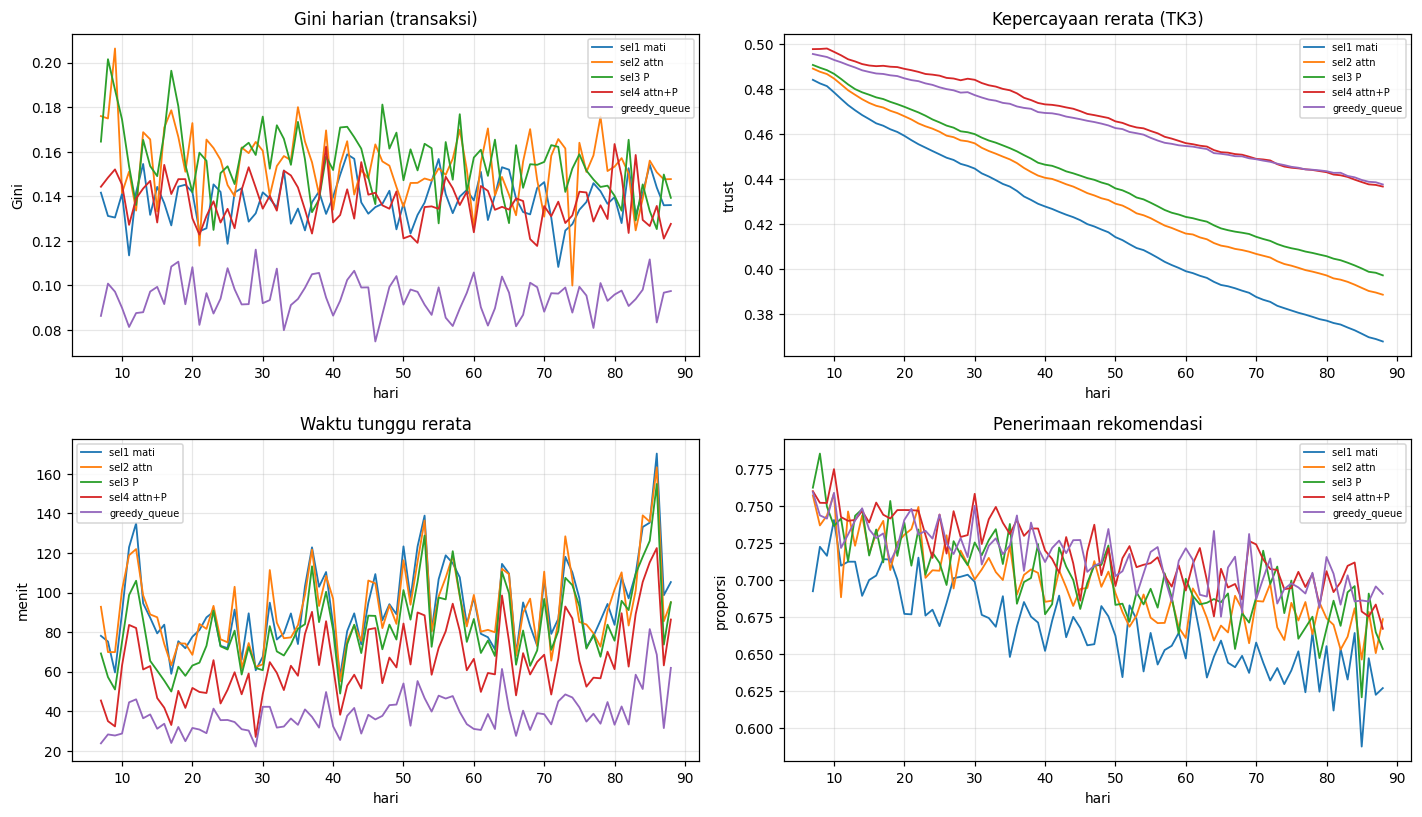

CATATAN: `gini_harian` pada berkas harian juga berbasis TRANSAKSI.
Lintasan Gini UTILISASI tidak tersimpan per hari -- hanya nilai akhir per run.


In [16]:
def plot_lin(metrik, judul, ylabel, ax):
    for n, t, l in LENGAN:
        s = A.lintasan(t, metrik, HORIZON, l, WARMUP)
        ax.plot(s['hari'], s['nilai'], label=n, lw=1.2)
    ax.set_title(judul); ax.set_xlabel('hari'); ax.set_ylabel(ylabel)
    ax.legend(fontsize=6.5)

fig, axes = plt.subplots(2, 2, figsize=(13, 7.5))
plot_lin('gini_harian', 'Gini harian (transaksi)', 'Gini', axes[0][0])
plot_lin('trust_mean',  'Kepercayaan rerata (TK3)', 'trust', axes[0][1])
plot_lin('wait_mean',   'Waktu tunggu rerata', 'menit', axes[1][0])
plot_lin('acceptance',  'Penerimaan rekomendasi', 'proporsi', axes[1][1])
plt.tight_layout(); plt.show()
print('CATATAN: `gini_harian` pada berkas harian juga berbasis TRANSAKSI.')
print('Lintasan Gini UTILISASI tidak tersimpan per hari -- hanya nilai akhir per run.')

## A.12 — Ringkasan Blok A

In [17]:
print('RINGKASAN BLOK A'.center(78, '='))
u_nama, u_tag, u_lg = USULAN
menang, kalah, tindih = [], [], []
for m in ['gini_UTIL', 'acc', 'wait', 'trust', 'rec_entropy', 'herding',
          'jnpatuh_expost_frac_untung', 'jnpatuh_expost_mean', 'pct_tepat']:
    f = (lambda t, l: A.gini_stasiun(t, 'gini_utilisasi', HORIZON, l)) if m == 'gini_UTIL' \
        else (lambda t, l: A.unit_stat(t, m, HORIZON, l))
    mu, _, vu, _ = f(u_tag, u_lg)
    arah = A.ARAH_BAIK.get(m, 'max')
    unggul, adatindih = True, False
    for n, t, l in GREEDY:
        mg, _, vg, _ = f(t, l)
        if not ((mu < mg) == (arah == 'min')):
            unggul = False
        if not (vu.max() < vg.min() or vg.max() < vu.min()):
            adatindih = True
    (menang if unggul and not adatindih else
     tindih if adatindih else kalah).append(m)
    print(f'  {m:28s} sel4={mu:9.4f}  ' +
          '  '.join(f'{n}={f(t,l)[0]:.4f}' for n, t, l in GREEDY))
print()
print(f'Unggul atas greedy_queue, rentang terpisah : {menang}')
print(f'Kalah                                      : {kalah}')
print(f'Ada tumpang tindih (jangan diklaim)        : {tindih}')
print()
print('CATATAN WAJIB untuk Bab V:')
print('  - n unit = 3 (RL) -> tak ada uji signifikansi yang dapat mencapai alpha=0,05;')
print('    inferensi bersifat deskriptif (ukuran efek + keterpisahan rentang).')
print('  - Metrik TK1 yang benar adalah gini_UTILISASI; angka gini transaksi pada')
print('    laporan-laporan sebelumnya memberi peringkat kebalikannya.')
print('  - greedy menikmati informasi antrean global sempurna; agen RL bekerja di')
print('    bawah observabilitas parsial. Bukan pembanding yang setara secara informasi.')
print('  - pct_tepat terkonfound dengan perutean (lihat A.7), bukan ukuran murni')
print('    kualitas estimasi.')

===============================RINGKASAN BLOK A===============================
  gini_UTIL                    sel4=   0.0206  greedy_queue=0.1163
  acc                          sel4=   0.7194  greedy_queue=0.7165


  wait                         sel4=  66.2480  greedy_queue=39.0510
  trust                        sel4=   0.4348  greedy_queue=0.4366
  rec_entropy                  sel4=   0.1182  greedy_queue=0.0000


  herding                      sel4=   0.3063  greedy_queue=0.4255
  jnpatuh_expost_frac_untung   sel4=   0.5385  greedy_queue=0.4074
  jnpatuh_expost_mean          sel4=  20.6793  greedy_queue=11.0938
  pct_tepat                    sel4=  37.7053  greedy_queue=51.5098

Unggul atas greedy_queue, rentang terpisah : ['gini_UTIL', 'rec_entropy', 'herding', 'jnpatuh_expost_frac_untung', 'jnpatuh_expost_mean']
Kalah                                      : ['wait', 'pct_tepat']
Ada tumpang tindih (jangan diklaim)        : ['acc', 'trust']

CATATAN WAJIB untuk Bab V:
  - n unit = 3 (RL) -> tak ada uji signifikansi yang dapat mencapai alpha=0,05;
    inferensi bersifat deskriptif (ukuran efek + keterpisahan rentang).
  - Metrik TK1 yang benar adalah gini_UTILISASI; angka gini transaksi pada
    laporan-laporan sebelumnya memberi peringkat kebalikannya.
  - greedy menikmati informasi antrean global sempurna; agen RL bekerja di
    bawah observabilitas parsial. Bukan pembanding yang setara secara